# Laboratorio 9 - Auditoria Avancada de Seguranca e Acesso

**Relatorio para entrega em PDF**  
Disciplina: Gestao de Sistemas de Informacao (GSI)  
Alunos: Lucas Garcia e Luis Augusto  
Prazo informado: 14/05

## 1. Objetivo do laboratorio

Auditar os logs de autenticacao do sistema core da TechStore S.A.
cruzando os acessos com a base de RH para localizar contas orfas,
acessos fora do horario comercial e logins bem-sucedidos vindos de
IPs externos. O notebook tambem registra evidencias de execucao,
exibe o dashboard visual e responde aos itens analiticos do roteiro.

## 2. Preparacao do ambiente

O roteiro pede `pandas`, `matplotlib` e `datetime`. Para manter o
codigo-fonte textual e reutilizavel, o notebook importa as rotinas
do script principal `auditoria_acessos.py`.

In [15]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

POSSIVEIS_DIRS = [Path.cwd(), Path.cwd() / "GSI" / "lab9"]
BASE_DIR = next(path for path in POSSIVEIS_DIRS if (path / "log_acessos_200_registros.csv").exists())
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from auditoria_acessos import (
    ARQUIVO_LOGS,
    ARQUIVO_RH,
    carregar_base_rh,
    carregar_logs,
    classificar_acessos_sucesso,
    cruzar_bases,
    executar_auditoria,
    gerar_analise_critica,
    gerar_sugestao_controle,
    identificar_contas_orfas,
    identificar_fora_horario,
    identificar_ips_externos_sucesso,
    identificar_usuarios_inativos_ou_bloqueados,
    montar_ranking_usuarios_risco,
    montar_resumo_classificacao,
    montar_resumo_incidentes,
)

LOG_PATH = BASE_DIR / "log_acessos_200_registros.csv"
RH_PATH = BASE_DIR / "usuarios_ativos_200_registros.csv"
OUT_DIR = BASE_DIR / "saidas"
LOG_PATH, RH_PATH

(WindowsPath('d:/Users/2023122760328/Desktop/SIIFES-IV/GSI/lab9/log_acessos_200_registros.csv'),
 WindowsPath('d:/Users/2023122760328/Desktop/SIIFES-IV/GSI/lab9/usuarios_ativos_200_registros.csv'))

## 3. Carga e entendimento das bases

Primeiro carregamos os dois CSVs, convertemos `data_hora` para
`datetime` e aplicamos o `merge` com `how='left'`, como pedido no
roteiro. Esse cruzamento preserva todos os acessos do log e apenas
agrega os dados do RH quando o usuario existe na base corporativa.

In [16]:
logs = carregar_logs(LOG_PATH)
rh = carregar_base_rh(RH_PATH)
cruzado = cruzar_bases(logs, rh)

print(f"Total de acessos no log: {len(logs)}")
print(f"Total de usuarios na base do RH: {len(rh)}")
print(f"Usuarios distintos no log: {logs['usuario'].nunique()}")
print(f"Usuarios distintos no RH: {rh['usuario'].nunique()}")
print()
cruzado.head(10)

Total de acessos no log: 200
Total de usuarios na base do RH: 200
Usuarios distintos no log: 15
Usuarios distintos no RH: 200



,id_acesso,usuario,data_hora,ip_origem,status,departamento,status_contrato,_merge,usuario_encontrado_rh,usuario_ativo,fora_horario,ip_externo
0,1,lucas_ti,2023-10-31 17:57:28,145.98.77.97,Falha,NaN,NaN,left_only,False,False,False,True
1,2,paulo_fin,2023-11-18 17:28:55,192.168.1.166,Sucesso,NaN,NaN,left_only,False,False,False,False
2,3,bruna_ads,2023-11-20 17:35:39,69.68.226.21,Sucesso,NaN,NaN,left_only,False,False,False,True
3,4,adm_jose,2023-11-08 18:55:36,1.243.75.38,Sucesso,NaN,NaN,left_only,False,False,True,True
4,5,paulo_fin,2023-11-27 08:42:26,192.168.1.177,Sucesso,NaN,NaN,left_only,False,False,False,False
5,6,joao_dev,2023-12-09 22:04:28,192.168.1.28,Sucesso,NaN,NaN,left_only,False,False,True,False
6,7,marina_mkt,2023-11-08 13:08:36,196.73.91.10,Sucesso,NaN,NaN,left_only,False,False,False,True
7,8,adm_jose,2023-11-26 00:48:16,60.190.86.73,Falha,NaN,NaN,left_only,False,False,True,True
8,9,rafael_ops,2023-11-05 23:59:30,192.168.1.17,Sucesso,NaN,NaN,left_only,False,False,True,False
9,10,bruna_ads,2023-11-20 02:35:09,204.251.218.145,Sucesso,NaN,NaN,left_only,False,False,True,True


A base de RH usa identificadores no formato `user001`, `user002`,
enquanto o log traz usuarios como `lucas_ti`, `paulo_fin` e
`tiago_suporte`. Essa diferenca de padrao ja sugere um problema de
governanca entre o cadastro de identidades e a trilha de acesso.

In [17]:
print("Usuarios unicos presentes no log:")
print(sorted(logs["usuario"].unique()))
print()
print("Primeiros usuarios do RH:")
print(rh["usuario"].head(15).tolist())

Usuarios unicos presentes no log:
['adm_jose', 'aline_com', 'ana_vendas', 'bruna_ads', 'camila_dp', 'carlos_rh', 'fernanda_sup', 'joao_dev', 'lucas_ti', 'marina_mkt', 'paulo_fin', 'rafael_ops', 'renato_log', 'sandra_gp', 'tiago_suporte']

Primeiros usuarios do RH:
['user001', 'user002', 'user003', 'user004', 'user005', 'user006', 'user007', 'user008', 'user009', 'user010', 'user011', 'user012', 'user013', 'user014', 'user015']


## 4. Tarefa 1 - Cruzamento de dados e contas orfas

Contas orfas sao acessos de usuarios que nao possuem correspondencia
valida na base do RH. Esse eh o achado mais critico do laboratorio,
porque indica falha no ciclo de vida de identidades.

In [18]:
contas_orfas = identificar_contas_orfas(cruzado)
usuarios_inativos = identificar_usuarios_inativos_ou_bloqueados(cruzado)

print(f"Acessos sem correspondencia no RH: {len(contas_orfas)}")
print(f"Acessos de usuarios existentes porem nao ativos: {len(usuarios_inativos)}")
display(contas_orfas.head(10))

Acessos sem correspondencia no RH: 200
Acessos de usuarios existentes porem nao ativos: 0


,id_acesso,usuario,data_hora,ip_origem,status,departamento,status_contrato,_merge,usuario_encontrado_rh,usuario_ativo,fora_horario,ip_externo
0,1,lucas_ti,2023-10-31 17:57:28,145.98.77.97,Falha,NaN,NaN,left_only,False,False,False,True
1,2,paulo_fin,2023-11-18 17:28:55,192.168.1.166,Sucesso,NaN,NaN,left_only,False,False,False,False
2,3,bruna_ads,2023-11-20 17:35:39,69.68.226.21,Sucesso,NaN,NaN,left_only,False,False,False,True
3,4,adm_jose,2023-11-08 18:55:36,1.243.75.38,Sucesso,NaN,NaN,left_only,False,False,True,True
4,5,paulo_fin,2023-11-27 08:42:26,192.168.1.177,Sucesso,NaN,NaN,left_only,False,False,False,False
5,6,joao_dev,2023-12-09 22:04:28,192.168.1.28,Sucesso,NaN,NaN,left_only,False,False,True,False
6,7,marina_mkt,2023-11-08 13:08:36,196.73.91.10,Sucesso,NaN,NaN,left_only,False,False,False,True
7,8,adm_jose,2023-11-26 00:48:16,60.190.86.73,Falha,NaN,NaN,left_only,False,False,True,True
8,9,rafael_ops,2023-11-05 23:59:30,192.168.1.17,Sucesso,NaN,NaN,left_only,False,False,True,False
9,10,bruna_ads,2023-11-20 02:35:09,204.251.218.145,Sucesso,NaN,NaN,left_only,False,False,True,True


## 5. Tarefa 2 - Auditoria de horario comercial

O horario permitido vai de 08:00 ate antes de 18:00. A celula abaixo
usa a hora extraida de `data_hora` para filtrar os acessos fora desse
intervalo.

In [19]:
fora_horario = identificar_fora_horario(cruzado)

print(f"Acessos fora do horario comercial: {len(fora_horario)}")
print(f"Acessos com sucesso fora do horario: {len(fora_horario[fora_horario['status'] == 'Sucesso'])}")
display(fora_horario.head(10))

Acessos fora do horario comercial: 106
Acessos com sucesso fora do horario: 85


,id_acesso,usuario,data_hora,ip_origem,status,departamento,status_contrato,_merge,usuario_encontrado_rh,usuario_ativo,fora_horario,ip_externo
3,4,adm_jose,2023-11-08 18:55:36,1.243.75.38,Sucesso,NaN,NaN,left_only,False,False,True,True
5,6,joao_dev,2023-12-09 22:04:28,192.168.1.28,Sucesso,NaN,NaN,left_only,False,False,True,False
7,8,adm_jose,2023-11-26 00:48:16,60.190.86.73,Falha,NaN,NaN,left_only,False,False,True,True
8,9,rafael_ops,2023-11-05 23:59:30,192.168.1.17,Sucesso,NaN,NaN,left_only,False,False,True,False
9,10,bruna_ads,2023-11-20 02:35:09,204.251.218.145,Sucesso,NaN,NaN,left_only,False,False,True,True
10,11,joao_dev,2023-11-05 07:19:23,192.168.1.243,Sucesso,NaN,NaN,left_only,False,False,True,False
13,14,sandra_gp,2023-11-08 02:22:24,192.168.1.18,Sucesso,NaN,NaN,left_only,False,False,True,False
14,15,renato_log,2023-11-30 07:57:26,192.168.1.234,Sucesso,NaN,NaN,left_only,False,False,True,False
20,21,ana_vendas,2023-12-05 05:56:54,178.165.212.177,Sucesso,NaN,NaN,left_only,False,False,True,True
21,22,lucas_ti,2023-10-25 02:09:19,192.168.1.10,Falha,NaN,NaN,left_only,False,False,True,False


## 6. Tarefa 3 - Identificacao de IPs externos

O roteiro pede a filtragem de acessos de sucesso cujo IP nao comeca
com `192.168`, simulando acessos externos nao autorizados pela VPN.

In [20]:
ips_externos_sucesso = identificar_ips_externos_sucesso(cruzado)

print(f"Acessos com sucesso vindos de IP externo: {len(ips_externos_sucesso)}")
display(ips_externos_sucesso.head(10))

Acessos com sucesso vindos de IP externo: 72


,id_acesso,usuario,data_hora,ip_origem,status,departamento,status_contrato,_merge,usuario_encontrado_rh,usuario_ativo,fora_horario,ip_externo
2,3,bruna_ads,2023-11-20 17:35:39,69.68.226.21,Sucesso,NaN,NaN,left_only,False,False,False,True
3,4,adm_jose,2023-11-08 18:55:36,1.243.75.38,Sucesso,NaN,NaN,left_only,False,False,True,True
6,7,marina_mkt,2023-11-08 13:08:36,196.73.91.10,Sucesso,NaN,NaN,left_only,False,False,False,True
9,10,bruna_ads,2023-11-20 02:35:09,204.251.218.145,Sucesso,NaN,NaN,left_only,False,False,True,True
16,17,tiago_suporte,2023-11-29 12:52:24,113.204.234.113,Sucesso,NaN,NaN,left_only,False,False,False,True
17,18,paulo_fin,2023-11-16 10:45:54,8.230.96.252,Sucesso,NaN,NaN,left_only,False,False,False,True
20,21,ana_vendas,2023-12-05 05:56:54,178.165.212.177,Sucesso,NaN,NaN,left_only,False,False,True,True
23,24,paulo_fin,2023-11-15 22:57:32,215.247.172.203,Sucesso,NaN,NaN,left_only,False,False,True,True
25,26,lucas_ti,2023-11-19 00:06:34,74.57.73.73,Sucesso,NaN,NaN,left_only,False,False,True,True
28,29,aline_com,2023-12-08 09:33:09,197.63.53.15,Sucesso,NaN,NaN,left_only,False,False,False,True


## 7. Tarefa 4 - Dashboard visual de riscos

Para evitar sobreposicao de rotulos e deixar o painel mais legivel,
a classificacao dos acessos com sucesso foi apresentada em barras
horizontais. Os acessos continuam classificados de forma exclusiva em
tres grupos:

1. `Acessos Autorizados`: usuario ativo no RH e dentro do horario.
2. `Violacoes de Horario`: usuario ativo no RH, mas fora do horario.
3. `Usuarios Inexistentes/Inativos`: usuario ausente no RH ou sem status ativo.

Como complemento, o dashboard tambem traz um segundo grafico de barras
horizontais com os contadores absolutos dos principais incidentes.

,categoria,quantidade
0,Acessos Autorizados,0
1,Violacoes de Horario,0
2,Usuarios Inexistentes/Inativos,161


,categoria,quantidade
0,Contas Orfas,200
1,Usuarios Inativos/Bloqueados,0
2,Acessos Fora do Horario,106
3,IPs Externos com Sucesso,72
4,Acessos Autorizados,0


Dashboard salvo em: d:\Users\2023122760328\Desktop\SIIFES-IV\GSI\lab9\saidas\dashboard_riscos.png


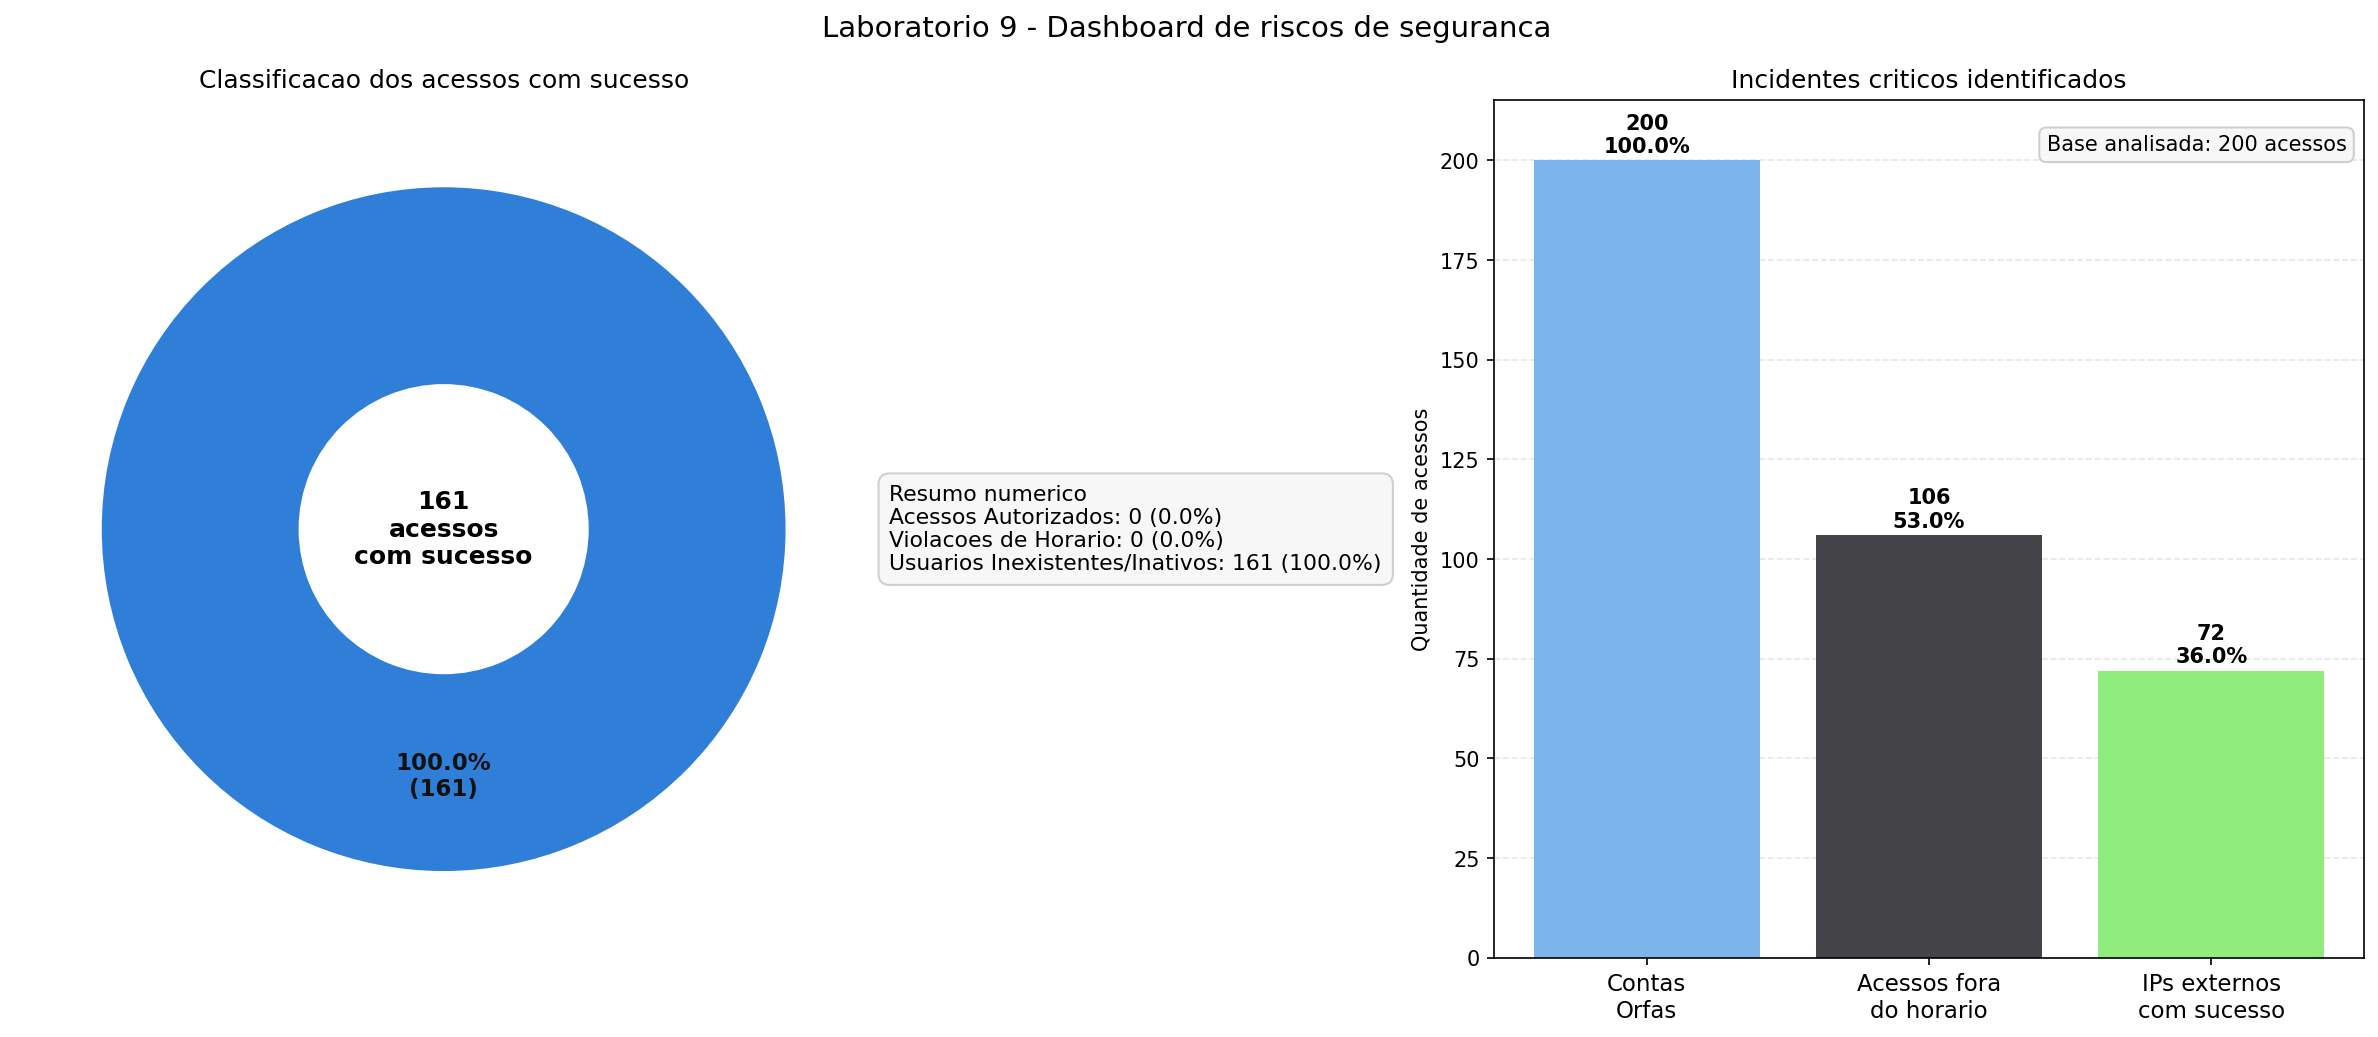

In [21]:
resultado = executar_auditoria(LOG_PATH, RH_PATH, OUT_DIR)
resumo_classificacao = resultado["resumo_classificacao"]
resumo_incidentes = resultado["resumo_incidentes"]

display(resumo_classificacao)
display(resumo_incidentes)
print(f"Dashboard salvo em: {resultado['dashboard']}")
Image(filename=str(resultado["dashboard"]))

## 8. Analise complementar

Alem do resumo geral, vale priorizar usuarios com maior volume de
acessos bem-sucedidos fora do horario e a partir de IPs externos.

In [22]:
ranking_riscos = montar_ranking_usuarios_risco(cruzado)
ranking_riscos.head(10)

,usuario,sucesso,sucesso_fora_horario,sucesso_ip_externo
6,fernanda_sup,14,10,7
4,camila_dp,11,8,6
14,tiago_suporte,15,8,5
1,aline_com,13,8,5
11,rafael_ops,12,7,6
12,renato_log,12,7,6
5,carlos_rh,10,7,4
2,ana_vendas,13,6,6
8,lucas_ti,8,6,4
13,sandra_gp,11,5,3


Nesta base, o cruzamento revela um problema estrutural: nenhum dos
15 usuarios do log aparece na base do RH. Como consequencia, os 161
acessos com sucesso ficam classificados como `Usuarios Inexistentes/Inativos`,
e nao existe nenhum acesso plenamente autorizado.

## 9. Codigo-fonte desenvolvido

O professor pediu que o codigo apareca de forma textual no arquivo
final. As celulas abaixo carregam os scripts usados nesta entrega.

In [23]:
def mostrar_codigo_fonte(nome_arquivo: str) -> None:
    caminho = BASE_DIR / nome_arquivo
    codigo = caminho.read_text(encoding="utf-8")
    display(Markdown(f"### Codigo-fonte: `{nome_arquivo}`"))
    display(Markdown(f"```python\n{codigo}\n```"))

for arquivo in ["auditoria_acessos.py", "test_auditoria_acessos.py"]:
    mostrar_codigo_fonte(arquivo)

### Codigo-fonte: `auditoria_acessos.py`

```python
"""Laboratorio 9 - Auditoria avancada de seguranca e acesso.

Script principal para cruzar logs de autenticacao com a base de RH,
identificar anomalias de acesso e gerar artefatos para o relatorio final.
"""

from __future__ import annotations

import os
from pathlib import Path
from typing import Any


BASE_DIR = Path(__file__).resolve().parent
os.environ.setdefault("MPLCONFIGDIR", str(BASE_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator


ARQUIVO_LOGS = BASE_DIR / "log_acessos_200_registros.csv"
ARQUIVO_RH = BASE_DIR / "usuarios_ativos_200_registros.csv"
PASTA_SAIDA = BASE_DIR / "saidas"

CATEGORIAS_CLASSIFICACAO = [
    "Acessos Autorizados",
    "Violacoes de Horario",
    "Usuarios Inexistentes/Inativos",
]


def carregar_logs(caminho_csv: Path) -> pd.DataFrame:
    """Carrega os logs e converte a data para ``datetime``."""
    df = pd.read_csv(caminho_csv)
    df["data_hora"] = pd.to_datetime(df["data_hora"])
    return df


def carregar_base_rh(caminho_csv: Path) -> pd.DataFrame:
    """Carrega a base de usuarios do RH."""
    return pd.read_csv(caminho_csv)


def cruzar_bases(logs: pd.DataFrame, rh: pd.DataFrame) -> pd.DataFrame:
    """Cruza logs com RH e adiciona flags operacionais para a auditoria."""
    df = logs.merge(rh, on="usuario", how="left", indicator=True)

    df["usuario_encontrado_rh"] = df["_merge"].eq("both")
    df["usuario_ativo"] = df["status_contrato"].eq("Ativo")
    df["fora_horario"] = (df["data_hora"].dt.hour < 8) | (
        df["data_hora"].dt.hour >= 18
    )
    df["ip_externo"] = ~df["ip_origem"].fillna("").astype(str).str.startswith("192.168")
    df = df.drop(columns=["_merge"])
    return df


def identificar_contas_orfas(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos de usuarios que nao aparecem na base do RH."""
    return df[~df["usuario_encontrado_rh"]].copy()


def identificar_usuarios_inativos_ou_bloqueados(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos de usuarios que existem no RH, mas nao estao ativos."""
    mascara = df["usuario_encontrado_rh"] & (~df["usuario_ativo"])
    return df[mascara].copy()


def identificar_acessos_irregulares_rh(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos de usuarios ausentes no RH ou sem status ativo."""
    mascara = (~df["usuario_encontrado_rh"]) | (~df["usuario_ativo"])
    return df[mascara].copy()


def identificar_acessos_sucesso_irregulares_rh(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos com sucesso por usuarios ausentes/inativos no RH."""
    mascara = df["status"].eq("Sucesso") & (
        (~df["usuario_encontrado_rh"]) | (~df["usuario_ativo"])
    )
    return df[mascara].copy()


def identificar_fora_horario(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna todos os acessos registrados fora do horario comercial."""
    return df[df["fora_horario"]].copy()


def identificar_ips_externos_sucesso(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos bem-sucedidos originados fora da faixa interna."""
    mascara = df["status"].eq("Sucesso") & df["ip_externo"]
    return df[mascara].copy()


def identificar_acessos_autorizados(df: pd.DataFrame) -> pd.DataFrame:
    """Retorna acessos bem-sucedidos por usuarios ativos e em horario comercial."""
    mascara = df["status"].eq("Sucesso") & df["usuario_ativo"] & (~df["fora_horario"])
    return df[mascara].copy()


def classificar_acessos_sucesso(df: pd.DataFrame) -> pd.DataFrame:
    """Classifica cada acesso bem-sucedido em uma categoria exclusiva."""
    sucessos = df[df["status"].eq("Sucesso")].copy()
    sucessos["classificacao"] = "Usuarios Inexistentes/Inativos"

    mascara_ativos = sucessos["usuario_ativo"]
    sucessos.loc[
        mascara_ativos & (~sucessos["fora_horario"]), "classificacao"
    ] = "Acessos Autorizados"
    sucessos.loc[
        mascara_ativos & sucessos["fora_horario"], "classificacao"
    ] = "Violacoes de Horario"
    return sucessos


def montar_resumo_classificacao(df: pd.DataFrame) -> pd.DataFrame:
    """Resume a classificacao exclusiva usada no grafico de pizza."""
    classificados = classificar_acessos_sucesso(df)
    contagens = (
        classificados["classificacao"]
        .value_counts()
        .reindex(CATEGORIAS_CLASSIFICACAO, fill_value=0)
    )
    return pd.DataFrame(
        {"categoria": list(contagens.index), "quantidade": list(contagens.values)}
    )


def montar_resumo_incidentes(df: pd.DataFrame) -> pd.DataFrame:
    """Resume os principais incidentes apurados na auditoria."""
    resumo = {
        "Contas Orfas": len(identificar_contas_orfas(df)),
        "Usuarios Inativos/Bloqueados": len(identificar_usuarios_inativos_ou_bloqueados(df)),
        "Acessos Fora do Horario": len(identificar_fora_horario(df)),
        "IPs Externos com Sucesso": len(identificar_ips_externos_sucesso(df)),
        "Acessos Autorizados": len(identificar_acessos_autorizados(df)),
    }
    return pd.DataFrame(
        {"categoria": list(resumo.keys()), "quantidade": list(resumo.values())}
    )


def montar_ranking_usuarios_risco(df: pd.DataFrame) -> pd.DataFrame:
    """Consolida indicadores por usuario para priorizacao operacional."""
    base = (
        df.assign(
            sucesso=df["status"].eq("Sucesso").astype(int),
            sucesso_fora_horario=(
                df["status"].eq("Sucesso") & df["fora_horario"]
            ).astype(int),
            sucesso_ip_externo=(
                df["status"].eq("Sucesso") & df["ip_externo"]
            ).astype(int),
        )
        .groupby("usuario", as_index=False)[
            ["sucesso", "sucesso_fora_horario", "sucesso_ip_externo"]
        ]
        .sum()
        .sort_values(
            ["sucesso_fora_horario", "sucesso_ip_externo", "sucesso"],
            ascending=False,
        )
    )
    return base


def _autopct_com_absoluto(valores: list[int]):
    total = max(sum(valores), 1)

    def formatador(pct: float) -> str:
        absoluto = int(round((pct / 100.0) * total))
        if absoluto == 0:
            return ""
        return f"{pct:.1f}%\n({absoluto})"

    return formatador


def _montar_resumo_numerico_pizza(resumo_classificacao: pd.DataFrame) -> str:
    """Monta um quadro textual com contagens e percentuais da pizza."""
    total = max(int(resumo_classificacao["quantidade"].sum()), 1)
    linhas = ["Resumo numerico"]

    for linha in resumo_classificacao.itertuples(index=False):
        percentual = (int(linha.quantidade) / total) * 100
        linhas.append(
            f"{linha.categoria}: {int(linha.quantidade)} ({percentual:.1f}%)"
        )

    return "\n".join(linhas)


def gerar_dashboard_visual(
    resumo_classificacao: pd.DataFrame,
    resumo_incidentes: pd.DataFrame,
    caminho_saida: Path,
    total_acessos: int | None = None,
) -> Path:
    """Gera um dashboard simples com pizza e barras."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    total_acessos = total_acessos or 0
    resumo_pizza = resumo_classificacao[
        resumo_classificacao["quantidade"] > 0
    ].copy()
    total_sucessos = int(resumo_classificacao["quantidade"].sum())

    if resumo_pizza.empty:
        resumo_pizza = pd.DataFrame(
            {"categoria": ["Sem acessos com sucesso"], "quantidade": [1]}
        )

    valores_pizza = resumo_pizza["quantidade"].tolist()
    cores_pizza = ["#2f7ed8", "#f45b5b", "#f7a35c"]
    wedges, _, autotextos = axes[0].pie(
        valores_pizza,
        autopct=_autopct_com_absoluto(valores_pizza),
        startangle=90,
        colors=cores_pizza[: len(valores_pizza)],
        pctdistance=0.72,
        wedgeprops={"width": 0.58, "edgecolor": "white"},
        textprops={"fontsize": 11, "fontweight": "bold"},
    )
    axes[0].set_title("Classificacao dos acessos com sucesso")
    axes[0].text(
        0,
        0,
        f"{total_sucessos}\nacessos\ncom sucesso",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )
    axes[0].text(
        1.02,
        0.5,
        _montar_resumo_numerico_pizza(resumo_classificacao),
        transform=axes[0].transAxes,
        ha="left",
        va="center",
        fontsize=10.5,
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f7f7f7", "edgecolor": "#cfcfcf"},
    )

    for texto in autotextos:
        if texto.get_text():
            texto.set_color("#111111")

    resumo_barras = resumo_incidentes[
        resumo_incidentes["categoria"].isin(
            ["Contas Orfas", "Acessos Fora do Horario", "IPs Externos com Sucesso"]
        )
    ]
    categorias_exibicao = [
        "Contas\nOrfas",
        "Acessos fora\ndo horario",
        "IPs externos\ncom sucesso",
    ]
    barras = axes[1].bar(
        categorias_exibicao,
        resumo_barras["quantidade"],
        color=["#7cb5ec", "#434348", "#90ed7d"],
    )
    axes[1].set_title("Incidentes criticos identificados")
    axes[1].set_ylabel("Quantidade de acessos")
    axes[1].tick_params(axis="x", rotation=0, labelsize=11)
    axes[1].set_ylim(0, max(resumo_barras["quantidade"].max(), 1) + 15)
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].grid(axis="y", linestyle="--", alpha=0.3)
    axes[1].set_axisbelow(True)
    axes[1].text(
        0.98,
        0.96,
        f"Base analisada: {total_acessos} acessos",
        transform=axes[1].transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "#f7f7f7", "edgecolor": "#cfcfcf"},
    )

    for barra in barras:
        altura = int(barra.get_height())
        percentual = (altura / total_acessos * 100) if total_acessos else 0
        axes[1].text(
            barra.get_x() + barra.get_width() / 2,
            altura + 1,
            f"{altura}\n{percentual:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    fig.suptitle("Laboratorio 9 - Dashboard de riscos de seguranca", fontsize=14)
    fig.subplots_adjust(wspace=0.42)
    fig.tight_layout()
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return caminho_saida


def salvar_evidencias(df: pd.DataFrame, pasta_saida: Path) -> dict[str, Path]:
    """Salva recortes e resumos usados no relatorio."""
    pasta_saida.mkdir(parents=True, exist_ok=True)
    arquivos = {
        "contas_orfas": pasta_saida / "acessos_contas_orfas.csv",
        "usuarios_irregulares_rh": pasta_saida / "acessos_usuarios_irregulares_rh.csv",
        "fora_horario": pasta_saida / "acessos_fora_horario.csv",
        "ips_externos_sucesso": pasta_saida / "acessos_ips_externos_sucesso.csv",
        "resumo_classificacao": pasta_saida / "resumo_classificacao.csv",
        "resumo_incidentes": pasta_saida / "resumo_incidentes.csv",
        "ranking_usuarios": pasta_saida / "ranking_usuarios_risco.csv",
    }

    identificar_contas_orfas(df).to_csv(arquivos["contas_orfas"], index=False)
    identificar_acessos_irregulares_rh(df).to_csv(
        arquivos["usuarios_irregulares_rh"], index=False
    )
    identificar_fora_horario(df).to_csv(arquivos["fora_horario"], index=False)
    identificar_ips_externos_sucesso(df).to_csv(
        arquivos["ips_externos_sucesso"], index=False
    )
    montar_resumo_classificacao(df).to_csv(
        arquivos["resumo_classificacao"], index=False
    )
    montar_resumo_incidentes(df).to_csv(arquivos["resumo_incidentes"], index=False)
    montar_ranking_usuarios_risco(df).to_csv(arquivos["ranking_usuarios"], index=False)
    return arquivos


def gerar_analise_critica(df: pd.DataFrame) -> str:
    """Responde a pergunta critica exigida no roteiro."""
    total_sucesso_irregular = len(identificar_acessos_sucesso_irregulares_rh(df))
    return (
        "A presenca de acessos com sucesso de usuarios fora da base do RH indica "
        "uma falha especifica no processo de offboarding e deprovisionamento de "
        "contas no IAM. Em termos praticos, a empresa nao esta reconciliando "
        "corretamente os eventos de desligamento do RH com a revogacao de acesso "
        "nos sistemas, o que mantem credenciais obsoletas ativas. Nesta base, "
        f"isso aparece em {total_sucesso_irregular} acessos com sucesso por "
        "usuarios sem correspondencia valida no cadastro de pessoal."
    )


def gerar_sugestao_controle(df: pd.DataFrame) -> str:
    """Descreve como um dashboard em tempo real pode mitigar os riscos."""
    total_fora_horario = len(identificar_fora_horario(df))
    total_ips_externos = len(identificar_ips_externos_sucesso(df))
    total_orfas = len(identificar_contas_orfas(df))
    return (
        "Um dashboard de BI em tempo real mitigaria esses riscos ao cruzar "
        "continuamente eventos de login com a base do RH e ao disparar alertas "
        "automaticos para tres sinais criticos: contas orfas, acessos fora do "
        "horario e IPs externos com sucesso. Nesta auditoria, o painel precisaria "
        f"destacar {total_orfas} acessos sem correspondencia no RH, "
        f"{total_fora_horario} acessos fora do horario comercial e "
        f"{total_ips_externos} acessos externos com sucesso, permitindo bloqueio "
        "preventivo, abertura de incidente e acompanhamento da equipe de seguranca "
        "quase em tempo real."
    )


def executar_auditoria(
    caminho_logs: Path = ARQUIVO_LOGS,
    caminho_rh: Path = ARQUIVO_RH,
    pasta_saida: Path = PASTA_SAIDA,
) -> dict[str, Any]:
    """Executa o fluxo completo da auditoria."""
    if not caminho_logs.exists():
        raise FileNotFoundError(f"Arquivo de logs nao encontrado: {caminho_logs}")
    if not caminho_rh.exists():
        raise FileNotFoundError(f"Arquivo de RH nao encontrado: {caminho_rh}")
    logs = carregar_logs(caminho_logs)
    rh = carregar_base_rh(caminho_rh)
    cruzado = cruzar_bases(logs, rh)
    resumo_classificacao = montar_resumo_classificacao(cruzado)
    resumo_incidentes = montar_resumo_incidentes(cruzado)
    dashboard = gerar_dashboard_visual(
        resumo_classificacao,
        resumo_incidentes,
        pasta_saida / "dashboard_riscos.png",
        total_acessos=len(cruzado),
    )
    arquivos = salvar_evidencias(cruzado, pasta_saida)

    return {
        "logs": logs,
        "rh": rh,
        "cruzado": cruzado,
        "resumo_classificacao": resumo_classificacao,
        "resumo_incidentes": resumo_incidentes,
        "dashboard": dashboard,
        "arquivos": arquivos,
        "analise_critica": gerar_analise_critica(cruzado),
        "sugestao_controle": gerar_sugestao_controle(cruzado),
    }


def main() -> None:
    """Ponto de entrada do script em linha de comando."""
    resultado = executar_auditoria()
    cruzado = resultado["cruzado"]
    resumo_classificacao = resultado["resumo_classificacao"]
    resumo_incidentes = resultado["resumo_incidentes"]

    print("=" * 64)
    print("LABORATORIO 9 - AUDITORIA AVANCADA DE SEGURANCA E ACESSO")
    print("=" * 64)
    print(f"Arquivo de logs: {ARQUIVO_LOGS.name}")
    print(f"Arquivo do RH:   {ARQUIVO_RH.name}")
    print(f"Total de acessos analisados: {len(cruzado)}")
    print(f"Usuarios distintos no log: {cruzado['usuario'].nunique()}")
    print()
    print("Resumo de classificacao dos acessos com sucesso:")
    print(resumo_classificacao.to_string(index=False))
    print()
    print("Resumo consolidado de incidentes:")
    print(resumo_incidentes.to_string(index=False))
    print()
    print("Amostra - contas orfas:")
    print(identificar_contas_orfas(cruzado).head(5).to_string(index=False))
    print()
    print("Amostra - acessos fora do horario:")
    print(identificar_fora_horario(cruzado).head(5).to_string(index=False))
    print()
    print("Amostra - IPs externos com sucesso:")
    print(identificar_ips_externos_sucesso(cruzado).head(5).to_string(index=False))
    print()
    print("Analise critica:")
    print(resultado["analise_critica"])
    print()
    print("Sugestao de controle:")
    print(resultado["sugestao_controle"])
    print()
    print(f"Dashboard salvo em: {resultado['dashboard']}")
    print(f"Evidencias salvas em: {PASTA_SAIDA}")


if __name__ == "__main__":
    main()

```

### Codigo-fonte: `test_auditoria_acessos.py`

```python
"""Testes do Laboratorio 9 - Auditoria avancada de seguranca e acesso."""

from __future__ import annotations

import sys
import unittest
from pathlib import Path

import pandas as pd

BASE_DIR = Path(__file__).resolve().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from auditoria_acessos import (
    ARQUIVO_LOGS,
    ARQUIVO_RH,
    carregar_base_rh,
    carregar_logs,
    classificar_acessos_sucesso,
    cruzar_bases,
    gerar_analise_critica,
    gerar_sugestao_controle,
    identificar_acessos_autorizados,
    identificar_contas_orfas,
    identificar_fora_horario,
    identificar_ips_externos_sucesso,
    identificar_usuarios_inativos_ou_bloqueados,
    montar_resumo_classificacao,
    montar_resumo_incidentes,
)


class AuditoriaAcessosTestCase(unittest.TestCase):
    """Valida as regras centrais do laboratorio 9."""

    @staticmethod
    def carregar_base_real() -> pd.DataFrame:
        logs = carregar_logs(Path(ARQUIVO_LOGS))
        rh = carregar_base_rh(Path(ARQUIVO_RH))
        return cruzar_bases(logs, rh)

    def test_contagens_da_base_real(self) -> None:
        cruzado = self.carregar_base_real()

        self.assertEqual(len(cruzado), 200)
        self.assertEqual(len(identificar_contas_orfas(cruzado)), 200)
        self.assertEqual(len(identificar_usuarios_inativos_ou_bloqueados(cruzado)), 0)
        self.assertEqual(len(identificar_fora_horario(cruzado)), 106)
        self.assertEqual(len(identificar_ips_externos_sucesso(cruzado)), 72)
        self.assertEqual(len(identificar_acessos_autorizados(cruzado)), 0)

    def test_classificacao_controlada(self) -> None:
        logs = pd.DataFrame(
            [
                {
                    "id_acesso": 1,
                    "usuario": "ana",
                    "data_hora": "2023-11-01 09:00:00",
                    "ip_origem": "192.168.1.10",
                    "status": "Sucesso",
                },
                {
                    "id_acesso": 2,
                    "usuario": "ana",
                    "data_hora": "2023-11-01 19:00:00",
                    "ip_origem": "192.168.1.20",
                    "status": "Sucesso",
                },
                {
                    "id_acesso": 3,
                    "usuario": "bruno",
                    "data_hora": "2023-11-01 10:00:00",
                    "ip_origem": "45.10.10.10",
                    "status": "Sucesso",
                },
                {
                    "id_acesso": 4,
                    "usuario": "carla",
                    "data_hora": "2023-11-01 11:00:00",
                    "ip_origem": "192.168.1.30",
                    "status": "Falha",
                },
            ]
        )
        logs["data_hora"] = pd.to_datetime(logs["data_hora"])

        rh = pd.DataFrame(
            [
                {"usuario": "ana", "departamento": "TI", "status_contrato": "Ativo"},
                {"usuario": "carla", "departamento": "RH", "status_contrato": "Inativo"},
            ]
        )

        cruzado = cruzar_bases(logs, rh)
        classificacao = classificar_acessos_sucesso(cruzado)
        resumo = montar_resumo_classificacao(cruzado)

        self.assertEqual(identificar_contas_orfas(cruzado)["id_acesso"].tolist(), [3])
        self.assertEqual(
            identificar_usuarios_inativos_ou_bloqueados(cruzado)["id_acesso"].tolist(),
            [4],
        )
        self.assertEqual(identificar_fora_horario(cruzado)["id_acesso"].tolist(), [2])
        self.assertEqual(
            identificar_ips_externos_sucesso(cruzado)["id_acesso"].tolist(), [3]
        )
        self.assertEqual(
            classificacao["classificacao"].tolist(),
            [
                "Acessos Autorizados",
                "Violacoes de Horario",
                "Usuarios Inexistentes/Inativos",
            ],
        )
        self.assertEqual(resumo["quantidade"].tolist(), [1, 1, 1])

    def test_resumos_e_textos_da_base_real(self) -> None:
        cruzado = self.carregar_base_real()
        resumo_classificacao = montar_resumo_classificacao(cruzado)
        resumo_incidentes = montar_resumo_incidentes(cruzado)
        analise = gerar_analise_critica(cruzado)
        sugestao = gerar_sugestao_controle(cruzado)

        self.assertEqual(
            resumo_classificacao["categoria"].tolist(),
            [
                "Acessos Autorizados",
                "Violacoes de Horario",
                "Usuarios Inexistentes/Inativos",
            ],
        )
        self.assertEqual(resumo_classificacao["quantidade"].tolist(), [0, 0, 161])
        self.assertEqual(
            resumo_incidentes["quantidade"].tolist(),
            [200, 0, 106, 72, 0],
        )
        self.assertIn("offboarding", analise.lower())
        self.assertIn("161", analise)
        self.assertIn("dashboard de BI".lower(), sugestao.lower())
        self.assertIn("200", sugestao)


if __name__ == "__main__":
    unittest.main()

```

## 10. Evidencias de execucao

As proximas celulas executam o script principal e a bateria de
testes. A saida fica incorporada ao notebook e pode ser mantida no
PDF final como evidencia objetiva da execucao.

In [24]:
comando_script = [sys.executable, str(BASE_DIR / "auditoria_acessos.py")]
resultado_script = subprocess.run(comando_script, capture_output=True, text=True, check=True)
print(resultado_script.stdout)
if resultado_script.stderr:
    print(resultado_script.stderr)

LABORATORIO 9 - AUDITORIA AVANCADA DE SEGURANCA E ACESSO
Arquivo de logs: log_acessos_200_registros.csv
Arquivo do RH:   usuarios_ativos_200_registros.csv
Total de acessos analisados: 200
Usuarios distintos no log: 15

Resumo de classificacao dos acessos com sucesso:
                     categoria  quantidade
           Acessos Autorizados           0
          Violacoes de Horario           0
Usuarios Inexistentes/Inativos         161

Resumo consolidado de incidentes:
                   categoria  quantidade
                Contas Orfas         200
Usuarios Inativos/Bloqueados           0
     Acessos Fora do Horario         106
    IPs Externos com Sucesso          72
         Acessos Autorizados           0

Amostra - contas orfas:
 id_acesso   usuario           data_hora     ip_origem  status departamento status_contrato  usuario_encontrado_rh  usuario_ativo  fora_horario  ip_externo
         1  lucas_ti 2023-10-31 17:57:28  145.98.77.97   Falha          NaN             NaN       

In [25]:
comando_testes = [sys.executable, "-m", "unittest", "-v", str(BASE_DIR / "test_auditoria_acessos.py")]
resultado_testes = subprocess.run(comando_testes, capture_output=True, text=True, check=True)
print(resultado_testes.stdout)
if resultado_testes.stderr:
    print(resultado_testes.stderr)


test_classificacao_controlada (test_auditoria_acessos.AuditoriaAcessosTestCase.test_classificacao_controlada) ... ok
test_contagens_da_base_real (test_auditoria_acessos.AuditoriaAcessosTestCase.test_contagens_da_base_real) ... ok
test_resumos_e_textos_da_base_real (test_auditoria_acessos.AuditoriaAcessosTestCase.test_resumos_e_textos_da_base_real) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.044s

OK



## 11. Analise critica pedida no roteiro

Pergunta: "A presenca de acessos com sucesso de usuarios fora da base
do RH indica qual falha especifica na Gestao de Identidade e Acesso (IAM)?"

In [26]:
print(gerar_analise_critica(cruzado))

A presenca de acessos com sucesso de usuarios fora da base do RH indica uma falha especifica no processo de offboarding e deprovisionamento de contas no IAM. Em termos praticos, a empresa nao esta reconciliando corretamente os eventos de desligamento do RH com a revogacao de acesso nos sistemas, o que mantem credenciais obsoletas ativas. Nesta base, isso aparece em 161 acessos com sucesso por usuarios sem correspondencia valida no cadastro de pessoal.


## 12. Sugestao de controle baseada em BI

Pergunta: "Baseado no conceito de BI, como um dashboard em tempo real
poderia mitigar esses riscos?"

In [27]:
print(gerar_sugestao_controle(cruzado))

Um dashboard de BI em tempo real mitigaria esses riscos ao cruzar continuamente eventos de login com a base do RH e ao disparar alertas automaticos para tres sinais criticos: contas orfas, acessos fora do horario e IPs externos com sucesso. Nesta auditoria, o painel precisaria destacar 200 acessos sem correspondencia no RH, 106 acessos fora do horario comercial e 72 acessos externos com sucesso, permitindo bloqueio preventivo, abertura de incidente e acompanhamento da equipe de seguranca quase em tempo real.


## 13. Conclusao

O laboratorio 9 foi concluido com os itens exigidos no roteiro:
cruzamento entre logs e RH, deteccao de contas orfas, filtro de
acessos fora do horario comercial, identificacao de IPs externos com
sucesso, dashboard visual de riscos, scripts em formato textual e
evidencias de execucao. Para entrega, este notebook pode ser exportado
diretamente para HTML ou PDF preservando o codigo, as tabelas e os
graficos.